# Sesión 2 - Práctica 3: Primer Agente Inteligente
## Implementación básica de Agent y GridWorld

**Técnicas de Sistemas Inteligentes - 2025/2026**

---

### Objetivos:
- Crear clase base `Agent`
- Implementar `Environment` (GridWorld simple)
- Ver el ciclo percepción-acción
- Preparar terreno para Práctica 1 (agente reactivo)

### VERSIÓN PARA CLASE EN VIVO
Algunas partes están incompletas - las completaremos juntos

## 1. Arquitectura de un Agente

Recordemos:

```
PERCEPCIÓN → RAZONAMIENTO → ACCIÓN
```

In [ ]:
class Agent:
    """Clase base para todos los agentes."""
    
    def __init__(self, name="Agent"):
        self.name = name
        self.alive = True
    
    def perceive(self, environment):
        """Percibir el entorno."""
        raise NotImplementedError("Subclass must implement perceive()")
    
    def decide(self, percept):
        """Decidir qué acción tomar."""
        raise NotImplementedError("Subclass must implement decide()")
    
    def act(self, action, environment):
        """Ejecutar acción en el entorno."""
        raise NotImplementedError("Subclass must implement act()")
    
    def __repr__(self):
        return f"<{self.name}>"

print("✓ Clase Agent base definida")

## 2. GridWorld: Entorno Simple 2D

Mundo grid donde:
- El agente puede moverse (UP, DOWN, LEFT, RIGHT)
- Hay celdas limpias y sucias
- El agente puede limpiar (CLEAN)

In [ ]:
import numpy as np
import random

class GridWorld:
    """Mundo grid 2D simple."""
    
    def __init__(self, width=5, height=5, dirty_prob=0.3):
        self.width = width
        self.height = height
        
        # Grid: 0=limpio, 1=sucio
        self.grid = np.zeros((height, width), dtype=int)
        
        # Inicializar celdas sucias aleatoriamente
        for i in range(height):
            for j in range(width):
                if random.random() < dirty_prob:
                    self.grid[i, j] = 1
        
        # Posición del agente
        self.agent_pos = [0, 0]
    
    def get_percept(self):
        """Retorna percepción actual del agente."""
        x, y = self.agent_pos
        is_dirty = (self.grid[y, x] == 1)
        
        return {
            'location': tuple(self.agent_pos),
            'dirty': is_dirty
        }
    
    def execute_action(self, action):
        """Ejecuta acción del agente."""
        x, y = self.agent_pos
        
        if action == 'UP':
            self.agent_pos[1] = max(0, y - 1)
            reward = -1
        
        elif action == 'DOWN':
            self.agent_pos[1] = min(self.height - 1, y + 1)
            reward = -1
        
        elif action == 'LEFT':
            self.agent_pos[0] = max(0, x - 1)
            reward = -1
        
        elif action == 'RIGHT':
            self.agent_pos[0] = min(self.width - 1, x + 1)
            reward = -1
        
        elif action == 'CLEAN':
            if self.grid[y, x] == 1:
                self.grid[y, x] = 0
                reward = 10
            else:
                reward = -1
        
        elif action == 'NOOP':
            reward = 0
        
        else:
            reward = -1
        
        return reward
    
    def is_clean(self):
        """Verifica si todo el grid está limpio."""
        return np.sum(self.grid) == 0
    
    def count_dirty(self):
        """Cuenta celdas sucias."""
        return np.sum(self.grid)
    
    def render(self):
        """Imprime el grid de forma visual."""
        print("┌" + "─" * (self.width * 2 - 1) + "┐")
        
        for y in range(self.height):
            row = "│"
            for x in range(self.width):
                if [x, y] == self.agent_pos:
                    row += "A"  # Agente
                elif self.grid[y, x] == 1:
                    row += "■"  # Sucio
                else:
                    row += "·"  # Limpio
                
                if x < self.width - 1:
                    row += " "
            
            row += "│"
            print(row)
        
        print("└" + "─" * (self.width * 2 - 1) + "┘")
        print(f"Celdas sucias: {self.count_dirty()}")
        print()

print("✓ Clase GridWorld definida")

### Probar el GridWorld

In [17]:
# Crear mundo
env = GridWorld(width=5, height=5, dirty_prob=0.4)

print("Estado inicial:")
env.render()

# Percibir
percept = env.get_percept()
print(f"Percepción: {percept}")
print()

# Ejecutar acciones
print("Limpiando celda actual...")
reward = env.execute_action('CLEAN')
print(f"Recompensa: {reward}")
env.render()

print("Moviendo a la derecha...")
reward = env.execute_action('RIGHT')
print(f"Recompensa: {reward}")
env.render()

Estado inicial:
┌─────────┐
│A ■ ■ · ·│
│■ · ■ · ■│
│· · ■ · ■│
│· · ■ · ■│
│· ■ ■ · ■│
└─────────┘
Celdas sucias: 13

Percepción: {'location': (0, 0), 'dirty': np.True_}

Limpiando celda actual...
Recompensa: 10
┌─────────┐
│A ■ ■ · ·│
│■ · ■ · ■│
│· · ■ · ■│
│· · ■ · ■│
│· ■ ■ · ■│
└─────────┘
Celdas sucias: 12

Moviendo a la derecha...
Recompensa: -1
┌─────────┐
│· A ■ · ·│
│■ · ■ · ■│
│· · ■ · ■│
│· · ■ · ■│
│· ■ ■ · ■│
└─────────┘
Celdas sucias: 12



## 3. EJERCICIO EN VIVO: Agente Reactivo Simple

Vamos a implementar juntos un agente que sigue reglas simples:
- **Si la celda está sucia** → LIMPIAR
- **Si está limpia** → MOVERSE aleatoriamente

In [19]:
import random

class SimpleReflexAgent(Agent):
    """Agente reactivo simple que limpia y se mueve."""
    
    def __init__(self, name="ReflexAgent"):
        super().__init__(name)
        self.actions_taken = []
    
    def perceive(self, environment):
        """Obtiene percepción del entorno."""
        return environment.get_percept()
    
    def decide(self, percept):
        """
        TODO: Implementar reglas del agente reactivo.
        
        Reglas:
        - IF percept['dirty'] == True THEN return 'CLEAN'
        - ELSE return movimiento aleatorio ('UP', 'DOWN', 'LEFT', 'RIGHT')
        
        Pista: usar random.choice() para elegir aleatoriamente
        """
        if percept['dirty']:
            return 'CLEAN'
        else:
            return random.choice(['UP', 'DOWN', 'LEFT', 'RIGHT'])
    
    def act(self, action, environment):
        """Ejecuta acción en el entorno."""
        self.actions_taken.append(action)
        return environment.execute_action(action)
    
    def run(self, environment, max_steps=50):
        """
        Ejecuta el agente en el entorno.
        
        TODO: Implementar el bucle principal del agente.
        
        Pasos:
        1. Para cada step hasta max_steps:
        2.   Percibir entorno
        3.   Decidir acción
        4.   Actuar
        5.   Acumular recompensa
        6.   Si todo limpio → terminar
        """
        total_reward = 0
        
        for step in range(max_steps):
            # TODO: Paso 1 - Percibir
            percept = self.perceive(environment)
            
            # TODO: Paso 2 - Decidir
            action = self.decide(percept)
            
            # TODO: Paso 3 - Actuar
            reward = self.act(action, environment)
            
            total_reward += reward
            
            # Mostrar estado cada 10 pasos
            if (step + 1) % 10 == 0 or environment.is_clean():
                print(f"--- Paso {step + 1} ---")
                print(f"Acción: {action}, Recompensa: {reward}")
                environment.render()
            
            # TODO: Paso 4 - Verificar si terminó
            if environment.is_clean():
                print(f"✓ ¡Todo limpio en {step + 1} pasos!")
                break
        
        return total_reward

print("✓ Clase SimpleReflexAgent definida (con gaps)")

✓ Clase SimpleReflexAgent definida (con gaps)


### Ejecutar el agente (una vez completado)

In [20]:
# Crear entorno y agente
env = GridWorld(width=5, height=5, dirty_prob=0.3)
agent = SimpleReflexAgent(name="Aspirador-1")

print("Estado inicial:")
env.render()

print("\nEjecutando agente...\n")
total_reward = agent.run(env, max_steps=100)

print(f"\nRecompensa total: {total_reward}")
print(f"Número de acciones: {len(agent.actions_taken)}")

Estado inicial:
┌─────────┐
│A · ■ · ■│
│· · · · ·│
│· · · ■ ·│
│■ · · ■ ·│
│· ■ · · ■│
└─────────┘
Celdas sucias: 7


Ejecutando agente...

--- Paso 10 ---
Acción: RIGHT, Recompensa: -1
┌─────────┐
│· · · · ·│
│· · · · A│
│· · · ■ ·│
│■ · · ■ ·│
│· ■ · · ■│
└─────────┘
Celdas sucias: 5

--- Paso 20 ---
Acción: DOWN, Recompensa: -1
┌─────────┐
│· · · · ·│
│· · · · A│
│· · · ■ ·│
│■ · · ■ ·│
│· ■ · · ■│
└─────────┘
Celdas sucias: 5

--- Paso 30 ---
Acción: RIGHT, Recompensa: -1
┌─────────┐
│· · · A ·│
│· · · · ·│
│· · · ■ ·│
│■ · · ■ ·│
│· ■ · · ■│
└─────────┘
Celdas sucias: 5

--- Paso 40 ---
Acción: RIGHT, Recompensa: -1
┌─────────┐
│· · · · ·│
│· · · · A│
│· · · · ·│
│■ · · ■ ·│
│· ■ · · ■│
└─────────┘
Celdas sucias: 4

--- Paso 50 ---
Acción: LEFT, Recompensa: -1
┌─────────┐
│· · · · ·│
│· · · · ·│
│· · · A ·│
│■ · · ■ ·│
│· ■ · · ■│
└─────────┘
Celdas sucias: 4

--- Paso 60 ---
Acción: CLEAN, Recompensa: 10
┌─────────┐
│· · · · ·│
│· · · · ·│
│· · · · ·│
│■ · · · ·│
│· A · · ■│
└──

## 4. Análisis del Agente

Vamos a evaluar el rendimiento del agente.

Resultados de 20 ejecuciones:
  Recompensa media: -45.8 ± 49.8
  Pasos medios: 129.4 ± 47.3
  Min pasos: 51, Max pasos: 200


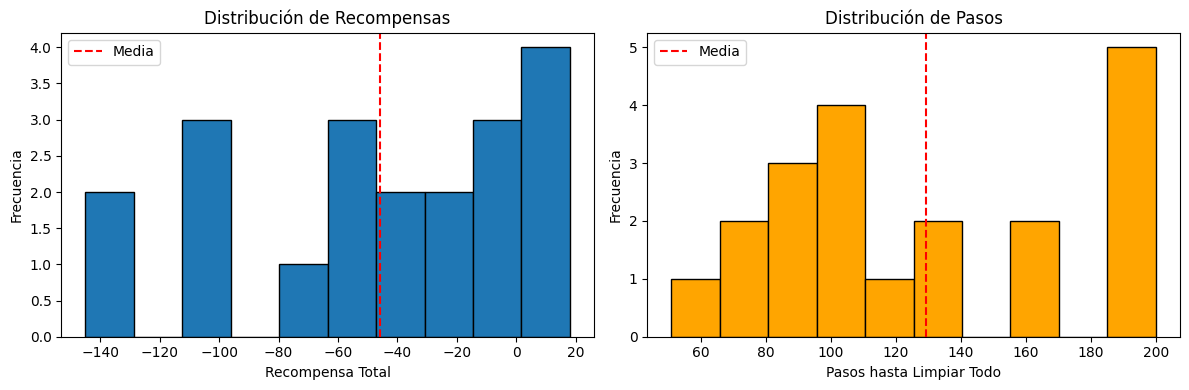

In [21]:
import matplotlib.pyplot as plt

def evaluate_agent(agent_class, n_trials=10, grid_size=5, dirty_prob=0.3):
    """Evalúa un agente en múltiples ejecuciones."""
    rewards = []
    steps_to_clean = []
    
    for trial in range(n_trials):
        env = GridWorld(width=grid_size, height=grid_size, dirty_prob=dirty_prob)
        agent = agent_class()
        
        total_reward = 0
        steps = 0
        
        for step in range(200):  # Max 200 pasos
            percept = agent.perceive(env)
            action = agent.decide(percept)
            reward = agent.act(action, env)
            
            total_reward += reward
            steps += 1
            
            if env.is_clean():
                break
        
        rewards.append(total_reward)
        steps_to_clean.append(steps)
    
    # Estadísticas
    print(f"Resultados de {n_trials} ejecuciones:")
    print(f"  Recompensa media: {np.mean(rewards):.1f} ± {np.std(rewards):.1f}")
    print(f"  Pasos medios: {np.mean(steps_to_clean):.1f} ± {np.std(steps_to_clean):.1f}")
    print(f"  Min pasos: {min(steps_to_clean)}, Max pasos: {max(steps_to_clean)}")
    
    # Gráficas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(rewards, bins=10, edgecolor='black')
    ax1.set_xlabel('Recompensa Total')
    ax1.set_ylabel('Frecuencia')
    ax1.set_title('Distribución de Recompensas')
    ax1.axvline(np.mean(rewards), color='red', linestyle='--', label='Media')
    ax1.legend()
    
    ax2.hist(steps_to_clean, bins=10, edgecolor='black', color='orange')
    ax2.set_xlabel('Pasos hasta Limpiar Todo')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Pasos')
    ax2.axvline(np.mean(steps_to_clean), color='red', linestyle='--', label='Media')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return rewards, steps

# Evaluar (comentado hasta completar el agente)
rewards, steps = evaluate_agent(SimpleReflexAgent, n_trials=20)

## 5. EJERCICIO EN VIVO: Agente con Memoria

El agente actual es completamente reactivo (sin memoria). Vamos a crear uno que recuerde dónde ha estado.

In [ ]:
class MemoryAgent(Agent):
    """Agente con memoria de celdas visitadas."""
    
    def __init__(self, name="MemoryAgent"):
        super().__init__(name)
        self.visited = set()  # Celdas ya visitadas
        self.actions_taken = []
    
    def perceive(self, environment):
        return environment.get_percept()
    
    def decide(self, percept):
        """
        TODO: Implementar estrategia con memoria.
        
        Estrategia:
        1. Añadir location actual a self.visited
        2. Si está sucia → limpiar
        3. Si está limpia:
           a) Calcular posibles movimientos
           b) Filtrar movimientos a celdas NO visitadas
           c) Si hay celdas no visitadas → ir a una
           d) Si todas visitadas → moverse aleatoriamente
        
        Pista: Los movimientos generan nuevas posiciones:
        'UP': (x, y-1), 'DOWN': (x, y+1), 'LEFT': (x-1, y), 'RIGHT': (x+1, y)
        """
        location = percept['location']
        
        # TODO: Paso 1 - Añadir a visitados
        # self.visited.add(location)
        
        # TODO: Paso 2 - Si está sucia, limpiar
        if percept['dirty']:
            return 'CLEAN'
        
        # TODO: Paso 3 - Intentar moverse a celda no visitada
        # Crear diccionario de movimientos posibles
        moves = {
            'UP': (location[0], location[1] - 1),
            'DOWN': (location[0], location[1] + 1),
            'LEFT': (location[0] - 1, location[1]),
            'RIGHT': (location[0] + 1, location[1])
        }
        
        # TODO: Filtrar movimientos a celdas no visitadas
        # unvisited_moves = [action for action, pos in moves.items() 
        #                   if pos not in self.visited]
        unvisited_moves = []  # COMPLETAR
        
        # TODO: Elegir acción
        if unvisited_moves:
            return random.choice(unvisited_moves)
        else:
            return random.choice(list(moves.keys()))
    
    def act(self, action, environment):
        self.actions_taken.append(action)
        return environment.execute_action(action)
    
    def run(self, environment, max_steps=50):
        """Similar a SimpleReflexAgent.run() - ya implementado."""
        total_reward = 0
        
        for step in range(max_steps):
            percept = self.perceive(environment)
            action = self.decide(percept)
            reward = self.act(action, environment)
            total_reward += reward
            
            if environment.is_clean():
                print(f"✓ Todo limpio en {step + 1} pasos")
                break
        
        return total_reward

print("✓ Clase MemoryAgent definida (con gaps)")

### Comparar ambos agentes (una vez completados)

In [ ]:
# Descomentar cuando los agentes estén completos

# print("=== Agente Reactivo Simple ===")
# rewards_simple, steps_simple = evaluate_agent(SimpleReflexAgent, n_trials=20)

# print("\n=== Agente con Memoria ===")
# rewards_memory, steps_memory = evaluate_agent(MemoryAgent, n_trials=20)

# print("\n=== COMPARACIÓN ===")
# print(f"Agente Simple:")
# print(f"  Pasos medios: {np.mean(steps_simple):.1f}")
# print(f"  Recompensa media: {np.mean(rewards_simple):.1f}")
# print()
# print(f"Agente con Memoria:")
# print(f"  Pasos medios: {np.mean(steps_memory):.1f}")
# print(f"  Recompensa media: {np.mean(rewards_memory):.1f}")
# print()

# mejora_pasos = (np.mean(steps_simple) - np.mean(steps_memory)) / np.mean(steps_simple) * 100
# print(f"Mejora en eficiencia: {mejora_pasos:.1f}% menos pasos")

## Resumen y Próximos Pasos

### Lo que hemos visto hoy:

1. **Estructuras de datos para IA**
   - Listas, tuplas, diccionarios, sets
   - Colas de prioridad con heapq
   - Clases para nodos de búsqueda

2. **NumPy básico**
   - Arrays para grids
   - Cálculo de distancias
   - Heurísticas

3. **Arquitectura de agentes**
   - Ciclo percepción-razonamiento-acción
   - Agentes reactivos simples
   - Agentes con memoria

### Próxima sesión (Sesión 3):

- Arquitectura BDI (Belief-Desire-Intention)
- Comunicación entre agentes (FIPA-ACL)
- Framework SPADE
- **Práctica 1**: Implementar agente reactivo completo + agente BDI básico

### Tarea para casa:

1. **Completar los gaps** de los notebooks si no dio tiempo en clase
2. Experimentar con diferentes tamaños de grid
3. Intentar mejorar el `MemoryAgent`:
   - ¿Puede planificar una ruta óptima?
   - ¿Puede priorizar celdas sucias cercanas?
4. Leer Russell & Norvig Cap. 2 (Agentes)